# Tutorial Part 1: Interpretable Machine Learning and Input Sensitivity
## Case Study: Comparing MLP Noise and CNN Geometric Regularization
### Audience: Mathematical Biology & Applied Mathematics (Colab-Native Workflow)

---

## 🎯 Executive Discovery Summary: What We Will Learn
In this mini-tutorial, we shift from regarding artificial neural networks as opaque, black-box systems to examining them as **differentiable multivariate vector functions**. We will discover how structural mathematical choices in network design fundamentally alter the stability, continuity, and interpretability of a model's local sensitivity landscape.

### Core Concepts to Uncover:
1. **The Gradient as a Sensitivity Operator:** If a model outputs a class score $z_c(\mathbf{x})$ for a target class $c$ given an image vector $\mathbf{x}$, the local Jacobian vector $\nabla_{\mathbf{x}} z_c(\mathbf{x}_0)$ acts as a first-order sensitivity coefficient. It reveals exactly how a localized perturbation to any single pixel coordinate scales the final functional output.
2. **The Space-Blindness of MLPs:** We begin with a Multi-Layer Perceptron (MLP). Because flattening an image into a 1D vector treats all pixels independently, the resulting local derivatives oscillate violently, creating high-frequency "television static" noise.
3. **Architecture as a Spatial Regularizer:** We then introduce a Convolutional Neural Network (CNN) to see how space-invariant operators force **spatial weight-sharing**. This choice fundamentally changes the gradient landscape into cohesive, continuous topological regions.

### ⚙️ Computational Tuning for a 2-Hour Flow
To maximize pedagogical clarity, we downsample standard MNIST observations from a $28 \times 28$ matrix to a mid-scale $20 \times 20$ grid. This modification balances structural fidelity (preserving fine strokes) with a tiny parameter footprint, allowing full model convergence in under 15 seconds natively inside Google Colab.

| Dimensional Metric | Standard MNIST Baseline | Our Pedagogical Layout |
| :--- | :--- | :--- |
| **Data Subsampling Pool** | 60,000 Train / 10,000 Test | 10,000 Train / 2,000 Test (Stratified) |
| **Spatial Resolution** | $28 \times 28 = 784$ features | $\mathbf{20 \times 20 = 400}$ features |
| **Total Parameter Scale** | ~235,000 weights/biases | **~15,000 - ~24,000 weights/biases** |
| **Colab Execution Latency** | ~2–3 Minutes | **~10–15 Seconds** |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Environment Confirmed. Target Version:", tf.__version__)

# Lock global pseudorandom seeds to ensure identical optimization trajectory across student runtimes
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow Environment Confirmed. Target Version: 2.21.0


## 1. Data Geometry: Stratification, Downsampling, and Vector Scaling

To maintain a controlled learning pace, we read the raw MNIST database and build a perfectly stratified partition containing exactly 1,000 training inputs and 200 verification inputs for each discrete digit class ($0, 1, \dots, 9$). 

Mathematically, we transform the original $28 \times 28$ structural grids down to a crisp $20 \times 20$ grid using a bilinear resizing operator $\mathcal{R}: \mathbb{R}^{28 \times 28} \to \mathbb{R}^{20 \times 20}$. Finally, we rescale discrete grayscale integer intensities from the bounded boundary $[0, 255]$ into a continuous compact interval $[0, 1] \subset \mathbb{R}$.

In [2]:
# 1. Load the native raw pixel arrays
(x_train_full, g_train_full), (x_test_full, g_test_full) = keras.datasets.mnist.load_data()

# 2. Define uniform stratified index sampling to isolate balanced class pools
def build_stratified_subset(images, labels, samples_per_class, seed=280):
    rng = np.random.default_rng(seed)
    selected_indices = np.concatenate([
        rng.choice(np.where(labels == digit)[0], size=samples_per_class, replace=False)
        for digit in range(10)
    ])
    rng.shuffle(selected_indices) 
    return images[selected_indices], labels[selected_indices]

x_train_raw, y_train = build_stratified_subset(x_train_full, g_train_full, samples_per_class=1000)
x_test_raw, y_test = build_stratified_subset(x_test_full, g_test_full, samples_per_class=200)

# 3. Execute Bilinear Scaling to Mid-Scale Resolution (28x28 -> 20x20)
x_train_20x20 = tf.image.resize(np.expand_dims(x_train_raw, axis=-1), (20, 20)).numpy().squeeze()
x_test_20x20 = tf.image.resize(np.expand_dims(x_test_raw, axis=-1), (20, 20)).numpy().squeeze()

# 4. Apply Linear Intensity Normalization
x_train = x_train_20x20 / 255.0
x_test = x_test_20x20 / 255.0

print(f"Optimized Training Tensor Geometry: {x_train.shape}")
print(f"Optimized Verification Tensor Geometry: {x_test.shape}")

Optimized Training Tensor Geometry: (10000, 20, 20)
Optimized Verification Tensor Geometry: (2000, 20, 20)


## 2. Core Baseline: The Multi-Layer Perceptron (MLP)

We begin by constructing a standard fully connected Multi-Layer Perceptron. In this layout, the 2D image matrix is flattened into a 1D vector $\mathbf{x} \in \mathbb{R}^{400}$. Because every input coordinate maps to every hidden layer node via completely independent scalar weights, the model is entirely **space-blind**—it has no built-in mathematical concept of neighboring pixels.

In [3]:
def compile_compact_mlp():
    model = keras.Sequential([
        layers.Flatten(input_shape=(20, 20), name='Flatten_Input'),
        layers.Dense(64, activation='relu', name='Hidden_Layer_1'),
        layers.Dense(32, activation='relu', name='Hidden_Layer_2'),
        layers.Dense(10, activation='softmax', name='Output_Layer')
    ], name="Compact_Pedagogical_MLP")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = compile_compact_mlp()
mlp_model.summary()

/Users/suzannesindi/miniforge3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Compact_Pedagogical_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Flatten_Input (Flatten)         │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_1 (Dense)          │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,074 (109.66 KB)

 Trainable params: 28,074 (109.66 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
print("Executing fast MLP model optimization routine...")
mlp_history = mlp_model.fit(
    x_train, y_train,
    epochs=12,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

Executing fast MLP model optimization routine...
Epoch 1/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8040 - loss: 0.6516 - val_accuracy: 0.9100 - val_loss: 0.3259
Epoch 2/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - accuracy: 0.9199 - loss: 0.2714 - val_accuracy: 0.9315 - val_loss: 0.2434
Epoch 3/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step - accuracy: 0.9421 - loss: 0.1970 - val_accuracy: 0.9365 - val_loss: 0.2137
Epoch 4/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - accuracy: 0.9541 - loss: 0.1538 - val_accuracy: 0.9435 - val_loss: 0.1932
Epoch 5/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - accuracy: 0.9633 - loss: 0.1241 - val_accuracy: 0.9470 - val_loss: 0.1781
Epoch 6/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - accuracy: 0.9697 - loss: 0.1013 - val_accuracy: 0.9505 - val_loss: 0.1773
Epoch 7/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - accuracy: 0.9748 - loss: 0.0834 - val_accuracy: 0.9460 - val_loss: 0.1938
Epoch 8/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - acc

## 3. Post-Hoc Sensitivity Mapping: The Input Gradient Vector

To analyze why our model outputs a specific categorical decision, we evaluate a local first-order **Taylor series expansion** at the coordinates of an isolated image vector $\mathbf{x}_0$. If we disturb the baseline image by a localized shift vector $\mathbf{\Delta x}$, the transformation of the class score $z_c(\mathbf{x}_0)$ is governed by:

$$z_c(\mathbf{x}_0 + \mathbf{\Delta x}) \approx z_c(\mathbf{x}_0) + \left[ \nabla_{\mathbf{x}} z_c(\mathbf{x}_0) \right]^T \mathbf{\Delta x}$$

The spatial vector gradient operator contains the system's local sensitivity coefficients:

$$\nabla_{\mathbf{x}} z_c(\mathbf{x}_0) = \left[ \frac{\partial z_c(\mathbf{x}_0)}{\partial x_{i,j}} \right] \in \mathbb{R}^{20 \times 20}$$

By evaluating the absolute value of these spatial components, we build a **Vanilla Saliency Map**:

$$\text{Saliency}_{i,j} = \left| \frac{\partial z_c(\mathbf{x}_0)}{\partial x_{i,j}} \right|$$

Because a neural network is highly non-linear, absolute gradient scales vary unpredictably between distinct images based on local flatness. To resolve this, we normalize each image independently using a **Robust Percentile Scaler**. We compute the 95th percentile threshold ($\mathcal{P}_{95}$) of the local gradient intensities, clip structural outlier noise spikes, and scale features cleanly between $[0, 1]$ relative to that local threshold baseline.

In [5]:
def compute_input_saliency(model, image, target_class):
    """
    Evaluates the localized absolute input gradient matrix for a chosen observation vector 
    utilizing TensorFlow's programmatic automatic differentiation engine.
    """
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    image_tensor = tf.expand_dims(image_tensor, axis=0)
    
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        predictions = model(image_tensor)
        class_score = predictions[0, target_class]
        
    gradient = tape.gradient(class_score, image_tensor)
    absolute_saliency = tf.squeeze(tf.abs(gradient)).numpy()
    return absolute_saliency

### Visualizing the MLP Saliency Landscape

We visualize our MLP results across three structural perspectives:
1. **Column 1:** The continuous downsampled $20 \times 20$ input image.
2. **Column 2:** The robustly scaled input gradient heatmap (`'hot'`).
3. **Column 3:** A binary mask isolating coordinates falling in the **top 5% of highest importance values** ($\ge \mathcal{P}_{95}$), outlined with a bright green (`'lime'`) contour boundary.

*Notice how disconnected and fragmented the MLP's important pixel regions look!*

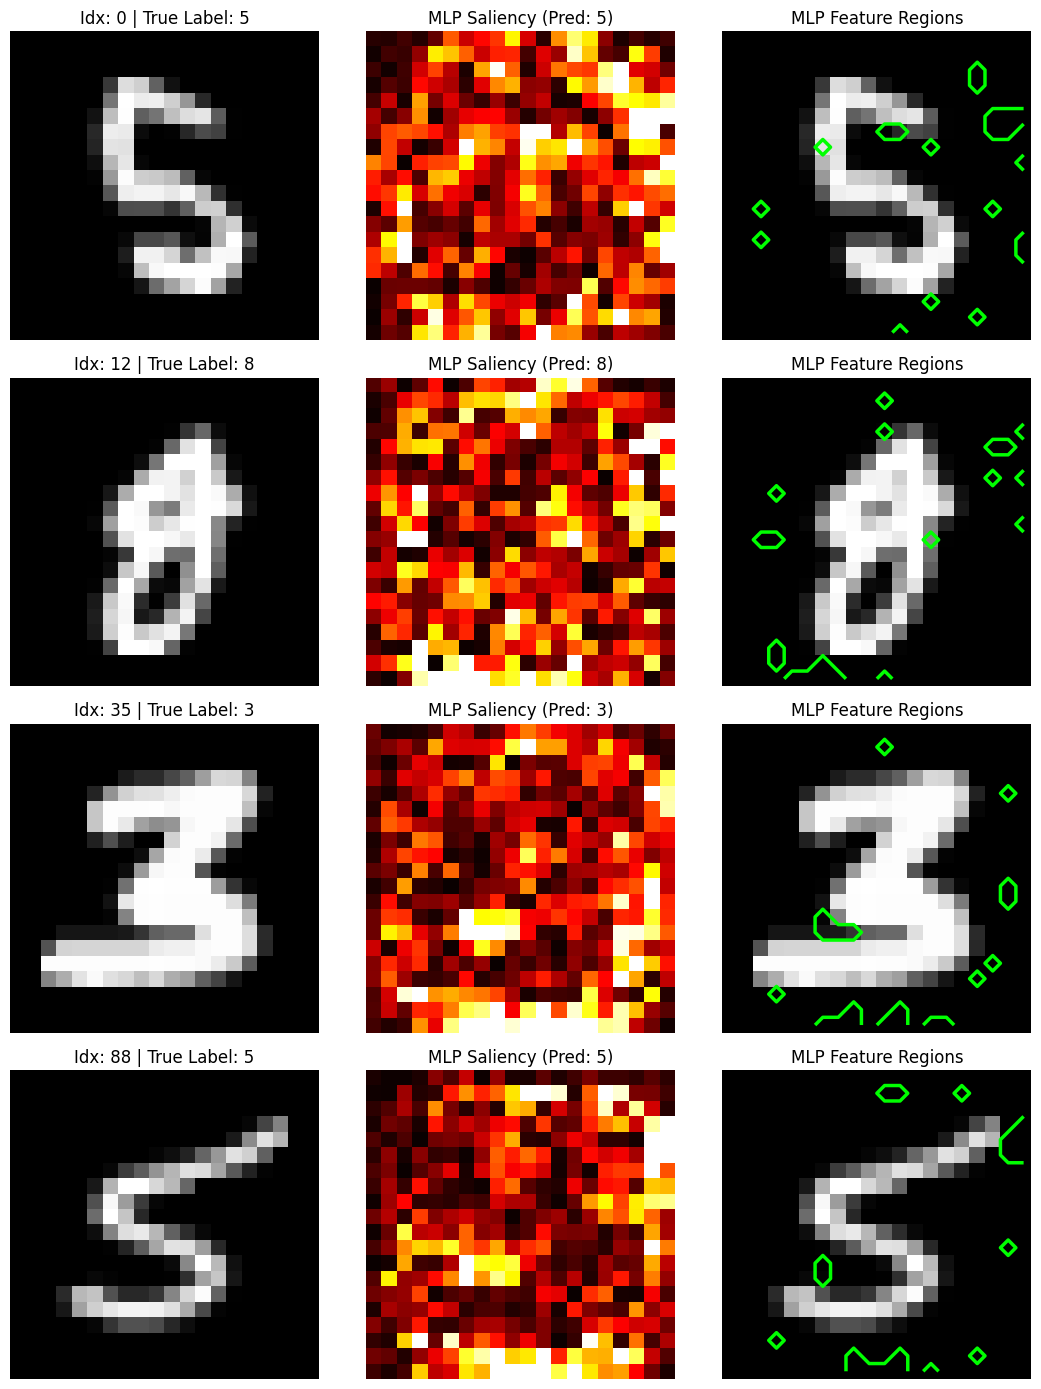

In [6]:
sample_indices = [0, 12, 35, 88]
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(11, 3.5 * len(sample_indices)))

for step, idx in enumerate(sample_indices):
    test_img = x_test[idx]
    true_label = y_test[idx]
    
    pred_probabilities = mlp_model.predict(tf.expand_dims(test_img, axis=0), verbose=0)
    predicted_class = np.argmax(pred_probabilities)
    
    saliency_map = compute_input_saliency(mlp_model, test_img, predicted_class)
    
    v_max = np.percentile(saliency_map, 95)
    clipped_saliency = np.clip(saliency_map, 0, v_max)
    normalized_saliency = clipped_saliency / (v_max + 1e-8)
    
    importance_mask = (saliency_map >= v_max).astype(float)
    
    # Column 1: Raw Input
    axes[step, 0].imshow(test_img, cmap='gray')
    axes[step, 0].set_title(f"Idx: {idx} | True Label: {true_label}")
    axes[step, 0].axis('off')
    
    # Column 2: MLP Heatmap
    axes[step, 1].imshow(normalized_saliency, cmap='hot', vmin=0, vmax=1)
    axes[step, 1].set_title(f"MLP Saliency (Pred: {predicted_class})")
    axes[step, 1].axis('off')
    
    # Column 3: Contour Overlay
    axes[step, 2].imshow(test_img, cmap='gray')
    if np.max(importance_mask) > 0:
        axes[step, 2].contour(importance_mask, levels=[0.5], colors='lime', linewidths=2.5)
    axes[step, 2].set_title("MLP Feature Regions")
    axes[step, 2].axis('off')

plt.tight_layout()
plt.show()

## 4. The Convolutional Alternative: Forcing a Geometric Prior

A **Convolutional Neural Network (CNN)** introduces space-invariant operators to preserve local structures. Instead of mapping independent weights to each coordinate, a compact localized kernel matrix $\mathbf{K} \in \mathbb{R}^{3 \times 3}$ slides systematically across the discrete 2D spatial coordinates.

Because adjacent inputs share common transformation parameters, backpropagation tracks partial derivatives directly through these shared spatial kernels. This forces a strong local correlation onto the input gradient vector, naturally regularizing the sensitivity map into **highly connected, cohesive topological paths** rather than isolated pixel confetti.

In [7]:
def compile_compact_cnn():
    model = keras.Sequential([
        layers.Reshape((20, 20, 1), input_shape=(20, 20)),
        layers.Conv2D(8, kernel_size=(3, 3), activation='relu', name='Spatial_Conv_1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='Max_Subsample_1'),
        layers.Flatten(name='Vector_Unroll'),
        layers.Dense(32, activation='relu', name='Hidden_Mixing'),
        layers.Dense(10, activation='softmax', name='Output_Projections')
    ], name="Compact_Pedagogical_CNN")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = compile_compact_cnn()
cnn_model.summary()

/Users/suzannesindi/miniforge3/lib/python3.12/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Compact_Pedagogical_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 20, 20, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Spatial_Conv_1 (Conv2D)         │ (None, 18, 18, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Subsample_1 (MaxPooling2D)  │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Vector_Unroll (Flatten)         │ (None, 648)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Mixing (Dense)           │ (None, 32)             │        20,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Projections (Dense)      │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,178 (82.73 KB)

 Trainable params: 21,178 (82.73 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("Executing fast CNN model optimization routine...")
cnn_history = cnn_model.fit(
    x_train, y_train,
    epochs=12,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

Executing fast CNN model optimization routine...
Epoch 1/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7776 - loss: 0.7257 - val_accuracy: 0.9130 - val_loss: 0.3182
Epoch 2/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9146 - loss: 0.2832 - val_accuracy: 0.9340 - val_loss: 0.2318
Epoch 3/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9409 - loss: 0.1987 - val_accuracy: 0.9515 - val_loss: 0.1835
Epoch 4/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9563 - loss: 0.1513 - val_accuracy: 0.9600 - val_loss: 0.1508
Epoch 5/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.1196 - val_accuracy: 0.9650 - val_loss: 0.1347
Epoch 6/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9718 - loss: 0.0973 - val_accuracy: 0.9645 - val_loss: 0.1253
Epoch 7/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9786 - loss: 0.0786 - val_accuracy: 0.9635 - val_loss: 0.1176
Epoch 8/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9821 

### The Revelation: Visualizing the CNN Saliency Landscape

Now, we run the exact same index samples through the trained CNN using our 3-column contour code. 

Observe how the green outlines transition from the fragmented pixel static of the MLP into **clean, continuous, highly localized curves and geometric envelopes** that outline the loops, crossings, and strokes of the actual handwriting.

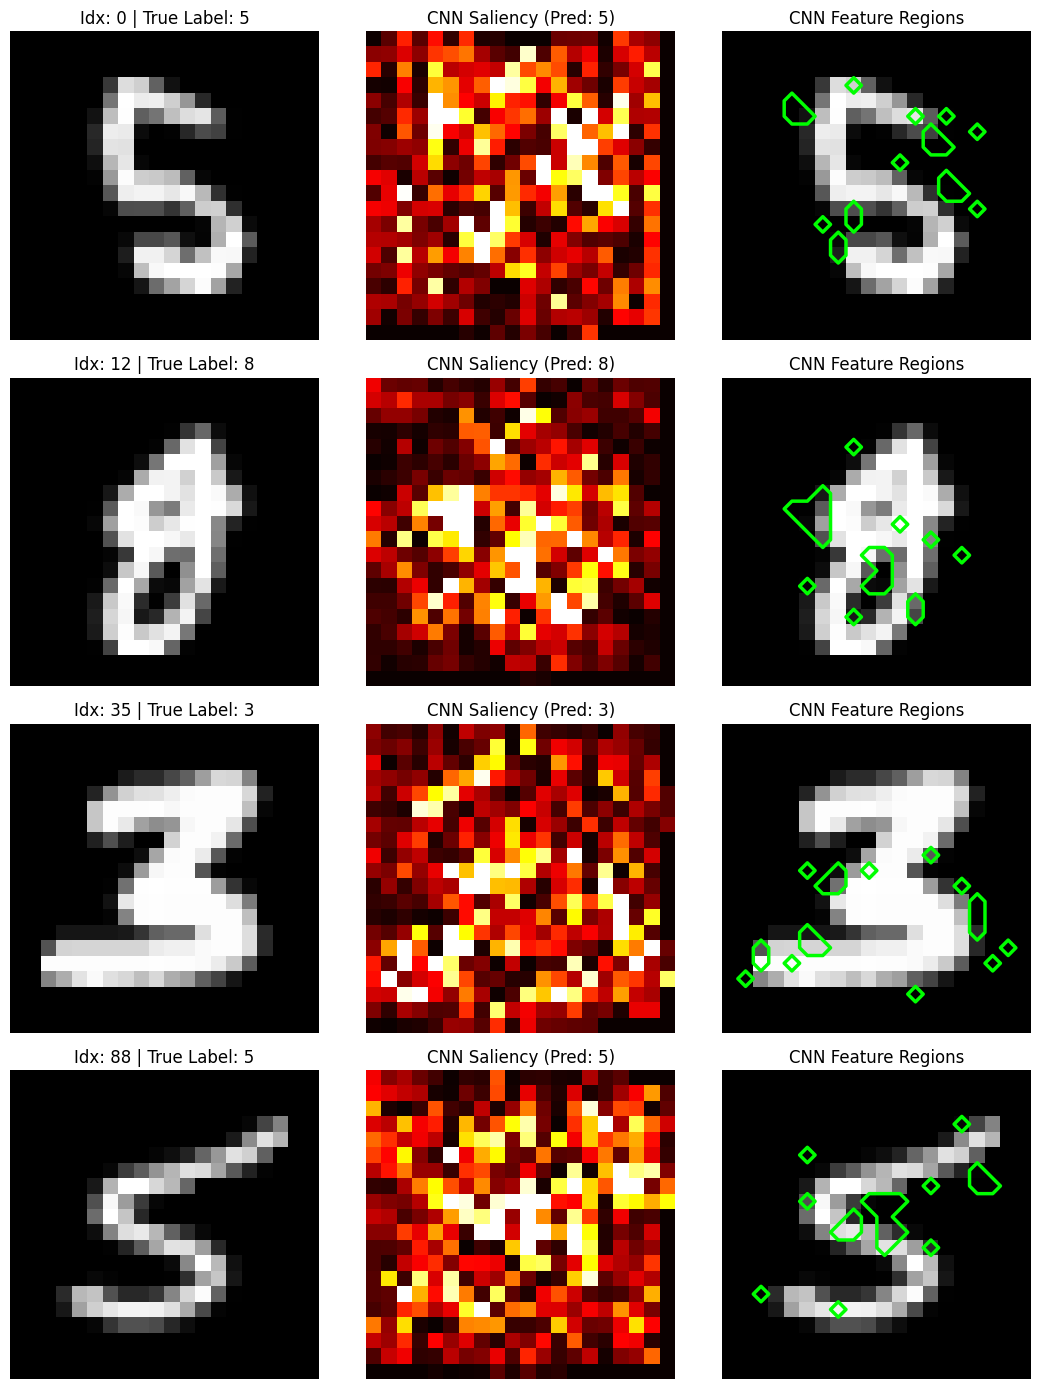

In [15]:
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(11, 3.5 * len(sample_indices)))

for step, idx in enumerate(sample_indices):
    test_img = x_test[idx]
    true_label = y_test[idx]
    
    pred_probabilities = cnn_model.predict(tf.expand_dims(test_img, axis=0), verbose=0)
    predicted_class = np.argmax(pred_probabilities)
    
    saliency_map = compute_input_saliency(cnn_model, test_img, predicted_class)
    
    v_max = np.percentile(saliency_map, 95)
    clipped_saliency = np.clip(saliency_map, 0, v_max)
    normalized_saliency = clipped_saliency / (v_max + 1e-8)
    
    importance_mask = (saliency_map >= v_max).astype(float)
    
    # Column 1: Raw Input
    axes[step, 0].imshow(test_img, cmap='gray')
    axes[step, 0].set_title(f"Idx: {idx} | True Label: {true_label}")
    axes[step, 0].axis('off')
    
    # Column 2: CNN Heatmap
    axes[step, 1].imshow(normalized_saliency, cmap='hot', vmin=0, vmax=1)
    axes[step, 1].set_title(f"CNN Saliency (Pred: {predicted_class})")
    axes[step, 1].axis('off')
    
    # Column 3: Contour Overlay
    axes[step, 2].imshow(test_img, cmap='gray')
    if np.max(importance_mask) > 0:
        axes[step, 2].contour(importance_mask, levels=[0.5], colors='lime', linewidths=2.5)
    axes[step, 2].set_title("CNN Feature Regions")
    axes[step, 2].axis('off')

plt.tight_layout()
plt.show()

## 5. Discussion Questions

1. **Understanding Local Sensitivity vs. Global Importance:** We are calculating the derivative of the output score with respect to the input pixels. If a region of pixels shows zero sensitivity, does it mean those pixels don't matter to the digit, or simply that the model's confidence landscape is locally flat there?
2. **Topology of the Contour Lines:** Notice that the green contours often highlight empty spaces (like the inner loops of an `8` or the open gap of a `3`). Why does an empty background region carry such a massive gradient value when discriminating between similar digit classes?
3. **Connecting Image Sensitivity to Dynamical Systems:** In mathematical biology, we use **parametric sensitivity analysis** to compute how state variables shift relative to parameter changes (e.g., evaluating the sensitivity matrix $\frac{\partial \mathbf{y}}{\partial \mathbf{p}}$ in biochemical pathways). How does tracking input sensitivity gradients in a neural network mirror analyzing parametric sensitivities to locate the critical drivers of a system bifurcation?